In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('tech_job_market_2019_2026.csv')
df.head(10)


,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
0,JOB041385,CobaltWealth,MNC,HealthTech,146085,Germany,SOC Analyst,Mid,3,5,...,2023-11-12 00:00:00,2023-11-20,Filled,98.0,4.0,5.0,5.0,-1,-1,N
1,JOB018462,DriftLearn,Mid-size,Cloud/Infra,5882,USA,Mobile Engineer (iOS),Mid,1,4,...,2025-06-29 00:00:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
2,JOB110011,AnchorBuzz Labs,MNC,HealthTech,186507,USA,QA Engineer,Lead,7,15,...,2026-01-24 00:00:00,2026-02-08,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,0
3,JOB073462,KiteSphere,Unicorn,HealthTech,10930,Brazil,Research Scientist,Entry,1,4,...,2020-12-09 00:00:00,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes
4,JOB051683,AetherNode Co,MNC,Social/AdTech,42510,USA,Product Manager,Senior,6,9,...,2025-07-19 00:00:00,2025-09-15,Filled,43.0,3.0,1.0,1.0,"$186,800",245400.0,1
5,JOB099770,QuantumBuzz Technologies,MNC,SaaS,86535,UK,Data Engineer,Intern,1,1,...,2025-09-09 00:00:00,2025-09-09,Filled,58.0,2.0,1.0,1.0,33100.0,38500.0,No
6,JOB080320,SpireCloud,MNC,Fintech,369939,USA,UI Designer,Entry,0,1,...,2022-06-16 00:00:00,2022-06-09,Filled,281.0,1.0,1.0,3.0,87400.0,98100.0,False
7,JOB057551,EchoCortex Co,MNC,Cybersecurity,128882,USA,Embedded Systems Engineer,Entry,0,4,...,2024-05-25 00:00:00,2024-05-29,Filled,258.0,3.0,1.0,1.0,131100.0,103900.0,N
8,JOB019108,NimbusFlow,FAANG-tier,Crypto/Web3,53256,UK,Product Designer,Mid,1,5,...,2022-04-21 00:00:00,2022-08-17,Filled,78.0,4.0,1.0,1.0,114500.0,139700.0,0
9,JOB088302,VantageChain Systems,Startup,AI/ML,380,Brazil,Product Designer,Intern,0,0,...,2025-05-23 00:00:00,2025-05-05,Filled,349.0,3.0,1.0,1.0,42500.0,47600.0,False


In [3]:
df.shape

(115000, 28)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115000 entries, 0 to 114999
Data columns (total 28 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   job_id                        115000 non-null  object 
 1   company_name                  115000 non-null  object 
 2   company_type                  115000 non-null  object 
 3   sector                        115000 non-null  object 
 4   company_size_employees        115000 non-null  int64  
 5   hq_country                    115000 non-null  object 
 6   job_role                      115000 non-null  object 
 7   seniority_level               115000 non-null  object 
 8   years_experience_min          115000 non-null  int64  
 9   years_experience_max          115000 non-null  int64  
 10  required_tech_stack           115000 non-null  object 
 11  primary_programming_language  92525 non-null   object 
 12  work_mode                     115000 non-nul

## there 21 object columns, 7 int columns

In [5]:
df.isnull().sum().sum()

np.int64(87962)

In this data there are 87962 missing data 


In [6]:
df.isnull().sum().sort_values(ascending=False)


date_position_filled            25781
job_location_city               25107
primary_programming_language    22475
application_deadline             5757
salary_max_usd                   3318
salary_min_usd                   3318
number_of_applicants             1110
number_of_interview_rounds        436
offers_accepted                   330
offers_extended                   330
job_id                              0
position_status                     0
posting_date                        0
salary_currency                     0
job_location_country                0
company_name                        0
visa_sponsorship_offered            0
work_mode                           0
required_tech_stack                 0
years_experience_max                0
years_experience_min                0
seniority_level                     0
job_role                            0
hq_country                          0
company_size_employees              0
sector                              0
company_type

In [7]:
null_val_cols = ["date_position_filled","job_location_city","primary_programming_language","application_deadline","salary_max_usd","salary_min_usd","number_of_applicants","number_of_interview_rounds","offers_accepted","offers_extended"]

In [8]:
df[df["job_id"].duplicated()].sort_values("job_id")

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
97744,JOB000012,KiteCare,Startup,Crypto/Web3,270,Brazil,DevOps Engineer,Lead,7,14,...,2022-09-14 00:00:00,2022-09-18,Filled,28.0,4.0,NaN,NaN,166200.0,205100.0,Y
64353,JOB000048,MeridianShield Labs,MNC,Social/AdTech,178480,India,Full Stack Engineer,Senior,5,11,...,2026-05-29 00:00:00,2026-06-12,Filled,93.0,3.0,1.0,1.0,139500.0,186300.0,No
48411,JOB000066,PinnacleBlock Inc,MNC,Cloud/Infra,40537,UK,Mobile Engineer (Android),Senior,6,9,...,2022-11-12 00:00:00,2022-12-05,Filled,71.0,3.0,5.0,5.0,160000.0,202200.0,1
59499,JOB000091,NexusCompute,FAANG-tier,Crypto/Web3,138397,Brazil,Cloud Engineer,Intern,1,1,...,2019-02-20 00:00:00,NaN,Cancelled,221.0,4.0,0.0,0.0,48300.0,61400.0,False
103282,JOB000141,GroveCapital,Startup,E-commerce,333,India,DevOps Engineer,Entry,0,2,...,2022-02-07 00:00:00,NaN,Filled,128.0,2.0,1.0,1.0,59000.0,64900.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17090,JOB111693,DriftDesk,Startup,SaaS,443,Germany,Product Manager,Mid,1,5,...,2022-02-19 00:00:00,NaN,Open,279.0,2.0,1.0,0.0,99200.0,127700.0,N
65945,JOB111860,SpireCloud,MNC,Fintech,241384,USA,Machine Learning Engineer,Mid,3,5,...,2019-09-12 00:00:00,2019-09-21,Filled,99.0,4.0,1.0,1.0,97000.0,114200.0,0
71126,JOB111885,NexusToken Technologies,Startup,Cloud/Infra,370,Australia,Machine Learning Engineer,Entry,0,1,...,2026-09-25 00:00:00,NaN,Open,119.0,1.0,6.0,4.0,64500.0,79900.0,0
36330,JOB111985,EmberReach Technologies,FAANG-tier,HealthTech,68660,UK,Machine Learning Engineer,Mid,2,5,...,2023-06-10 00:00:00,2023-07-18,Filled,153.0,4.0,1.0,1.0,125100.0,166000.0,N


Here as we see there us 2000 rows which is duplicated on the basis of job_id 

In [9]:
df.drop_duplicates(subset=["job_id"], inplace=True)
df["job_id"].duplicated().sum()

np.int64(0)

In [10]:
df.shape

(113000, 28)

In [11]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"Column: {col}")
    print(df[col].unique())
    print("\n")

Column: job_id
['JOB041385' 'JOB018462' 'JOB110011' ... 'JOB006013' 'JOB063108'
 'JOB006559']


Column: company_name
['CobaltWealth' 'DriftLearn' 'AnchorBuzz Labs' 'KiteSphere'
 'AetherNode Co' 'QuantumBuzz Technologies' 'SpireCloud' 'EchoCortex Co'
 'NimbusFlow' 'VantageChain Systems' 'PinnacleBlock'
 'EchoVita Technologies' 'MeridianToken' 'BeaconStack Co'
 'LumenArcade Technologies' 'VertexCompute Inc' 'PinnacleLedger Labs'
 'AstraCognition' 'PrismSphere' 'NovaFleet' 'PrismRoute Technologies'
 'MeridianShield Labs' 'DriftGame Co' 'DriftSkill Inc' 'RidgeAI'
 'CatalystWellness Inc' 'EchoTrade Co' 'OnyxBuzz Inc' 'NexusShield'
 'FusionTrade' 'VantageSphere' 'CobaltAcademy Labs' 'SolaceFlow Inc'
 'AstraSuite' 'SolaceShop Labs' 'VantageFlow' 'DriftGame'
 'LumenNeural Inc' 'LatticeReach Systems' 'SpireBazaar Co' 'OrbitWorks'
 'KitePlay Inc' 'NimbusGame Technologies' 'LUMENARCADE TECHNOLOGIES'
 'DriftShield Labs' '  OnyxBuzz Co' 'CrestMind Systems' 'NovaCare'
 'TideFort' 'AetherFleet Inc' '

- By this we can see that for (layoff_within_12_months_flag , visa_sponsorship_offered) the data is written in different format
- In this we can see that min and max salary are in str we have to covert it into int

In [12]:
df["layoff_within_12_months_flag"] = df["layoff_within_12_months_flag"].map({'N':"No", '0' : "No", '1' : "Yes" ,'False':"No" ,'Y':"Yes", 'True':"Yes"})
df["visa_sponsorship_offered"] = df["visa_sponsorship_offered"].map({'N':"No", '0' : "No", '1' : "Yes" ,'False':"No" ,'Y':"Yes", 'True':"Yes"})

df["salary_min_usd"] = pd.to_numeric(df["salary_min_usd"], errors="coerce").astype("Int64")
df["salary_max_usd"] = pd.to_numeric(df["salary_max_usd"], errors="coerce").astype("Int64")

print(df["layoff_within_12_months_flag"].unique())
print(df["visa_sponsorship_offered"].unique())

['No' nan 'Yes']
['No' nan 'Yes']


In [13]:
df[df['salary_min_usd'] > df['salary_max_usd']]

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
7,JOB057551,EchoCortex Co,MNC,Cybersecurity,128882,USA,Embedded Systems Engineer,Entry,0,4,...,2024-05-25 00:00:00,2024-05-29,Filled,258.0,3.0,1.0,1.0,131100,103900,No
187,JOB080791,NexusShield,MNC,E-commerce,335703,India,Cloud Engineer,Senior,5,11,...,2024-12-07 00:00:00,2025-01-05,Filled,60.0,3.0,1.0,1.0,153900,132400,No
335,JOB102070,VertexCompute Inc,MNC,HealthTech,100246,India,SOC Analyst,Senior,6,10,...,2025-01-24 00:00:00,2025-03-06,Filled,168.0,4.0,1.0,1.0,182900,140800,No
702,JOB003325,OnyxSphere Inc,Mid-size,Gaming,6442,USA,Embedded Systems Engineer,Mid,3,7,...,2026-03-10 00:00:00,2026-02-02,Filled,276.0,3.0,1.0,1.0,71800,65300,No
1231,JOB040177,TideCognition Technologies,Unicorn,Crypto/Web3,15512,Australia,Security Engineer,Senior,6,9,...,2023-02-20 00:00:00,2023-02-23,Filled,52.0,5.0,1.0,1.0,208900,169200,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114054,JOB110290,NimbusAcademy,Mid-size,E-commerce,4526,France,Application Security Engineer,Senior,6,9,...,2021-04-20 00:00:00,2021-03-26,Filled,128.0,5.0,1.0,1.0,166200,123800,No
114107,JOB077294,VertexCompute Inc,MNC,HealthTech,75526,India,Software Engineer,Principal,13,24,...,2026-09-20 00:00:00,2026-09-03,Filled,30.0,5.0,1.0,1.0,209300,167400,No
114168,JOB062092,NexusShield,MNC,E-commerce,295592,India,Penetration Tester,Mid,3,5,...,2026-05-12 00:00:00,2026-05-28,Filled,91.0,2.0,1.0,1.0,112100,86700,No
114235,JOB007311,MeridianCare Systems,Startup,E-commerce,406,Australia,Analytics Engineer,Mid,2,5,...,NaN,2022-06-20,Filled,97.0,4.0,1.0,1.0,125300,93600,NaN


In [14]:
df.drop(df[df['salary_min_usd'] > df['salary_max_usd']].index, inplace=True, axis=0)

In [15]:
df.describe()

,company_size_employees,years_experience_min,years_experience_max,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd
count,112563.000000,112563.000000,112563.000000,111466.000000,112132.000000,112236.000000,112236.000000,107261.0,108623.0
mean,105393.428169,3.004175,6.665050,181.869745,3.308092,1.348560,1.195918,114540.708785,141787.272263
std,102107.224215,3.093260,5.073785,438.698480,1.418512,1.455033,1.121905,57516.499623,91785.409717
min,10.000000,0.000000,0.000000,-5.000000,1.000000,0.000000,0.000000,-1.0,-1.0
25%,6042.000000,1.000000,3.000000,62.000000,2.000000,1.000000,1.000000,75800.0,92000.0
50%,88368.000000,2.000000,6.000000,119.000000,3.000000,1.000000,1.000000,105300.0,128200.0
75%,169850.000000,5.000000,9.000000,213.000000,4.000000,1.000000,1.000000,145700.0,177500.0
max,488674.000000,24.000000,24.000000,36816.000000,8.000000,8.000000,10.000000,531800.0,3552000.0


1. In no of applicant min value is -5 which not possible 
2. Also in min_salary and max_salary value is -1 which not possible 
3. for company_size_employees, number_of_applicants, offers_accepted, offers_extended Mean and sd is similar means it is highly spreadable

In [16]:
df.drop(df[df['salary_max_usd']<0].index, inplace=True, axis=0)
df.drop(df[df['salary_min_usd']<0].index, inplace=True, axis=0)
df.drop(df[df['number_of_applicants']<0].index, inplace=True, axis=0)


## UNIVARIATE

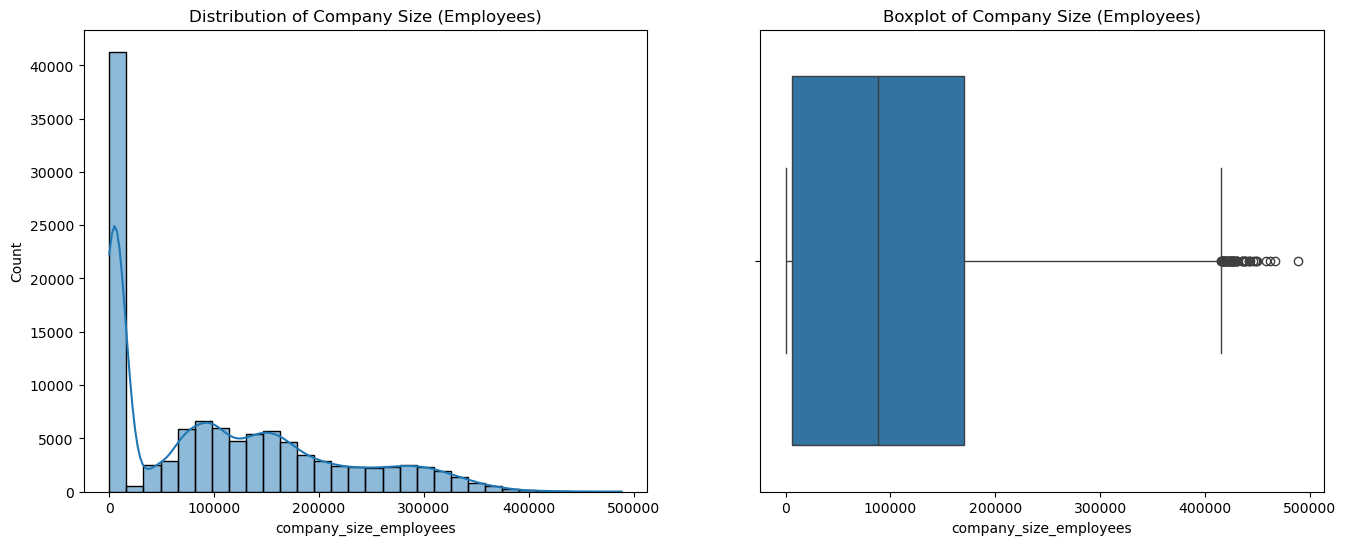

In [17]:
# company_size_employees
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
sns.histplot(df['company_size_employees'], bins=30, kde=True)
plt.title('Distribution of Company Size (Employees)')

plt.subplot(1,2,2)
sns.boxplot(x='company_size_employees', data=df)
plt.title('Boxplot of Company Size (Employees)')

plt.show()

Mostly company have smaller Company_size_employee but few company has larger size 

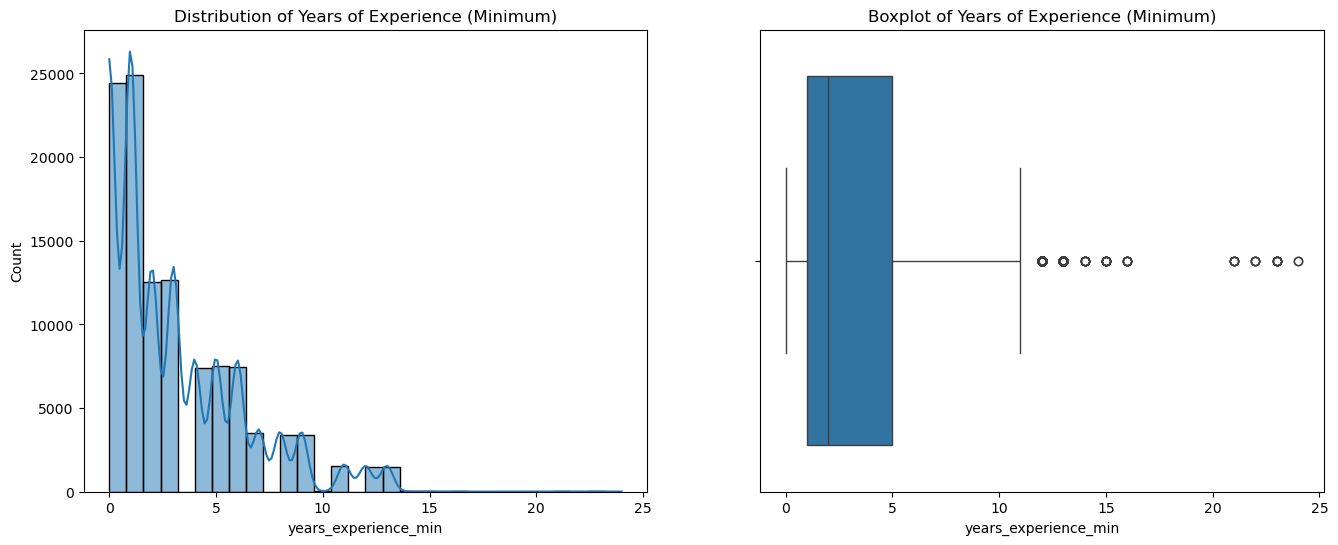

In [18]:
# years_experience_min
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
sns.histplot(df['years_experience_min'], bins=30, kde=True)
plt.title('Distribution of Years of Experience (Minimum)')

plt.subplot(1,2,2)
sns.boxplot(x='years_experience_min', data=df)
plt.title('Boxplot of Years of Experience (Minimum)')

plt.show()

Minimum Expierence needed for a company is mostly 0-5 year but there ar company needed more expierenced employee

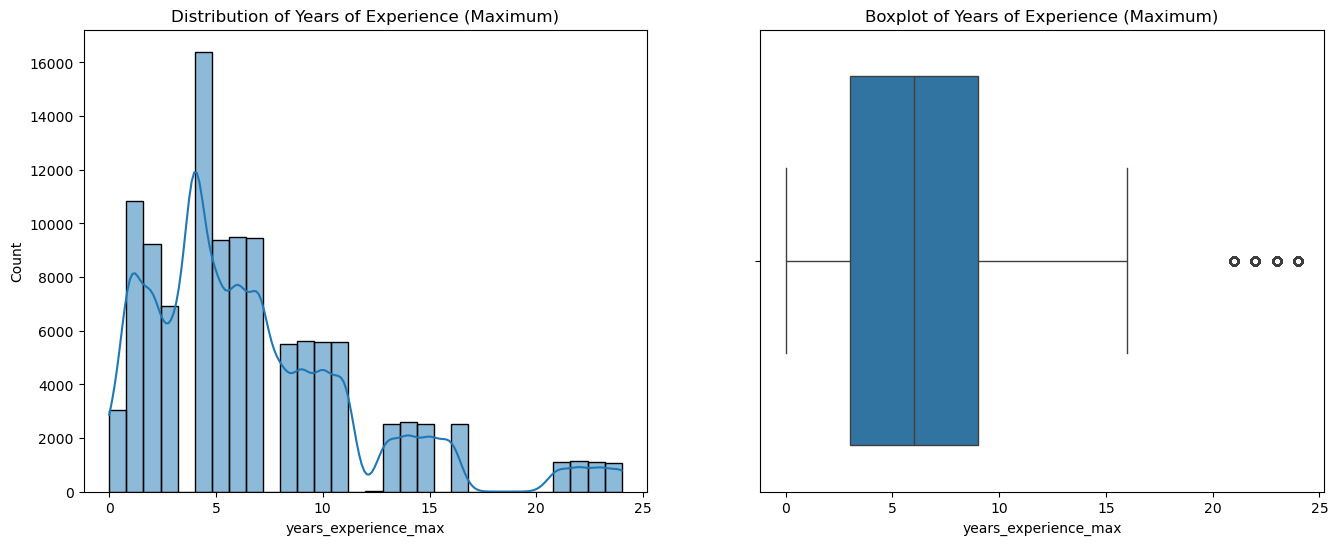

In [19]:
# years_experience_max
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
sns.histplot(df['years_experience_max'], bins=30, kde=True)
plt.title('Distribution of Years of Experience (Maximum)')

plt.subplot(1,2,2)
sns.boxplot(x='years_experience_max', data=df)
plt.title('Boxplot of Years of Experience (Maximum)')

plt.show()

Maximum Expierence needed for a company is mostly 1-10 year but there are company that allow more expierenced employee

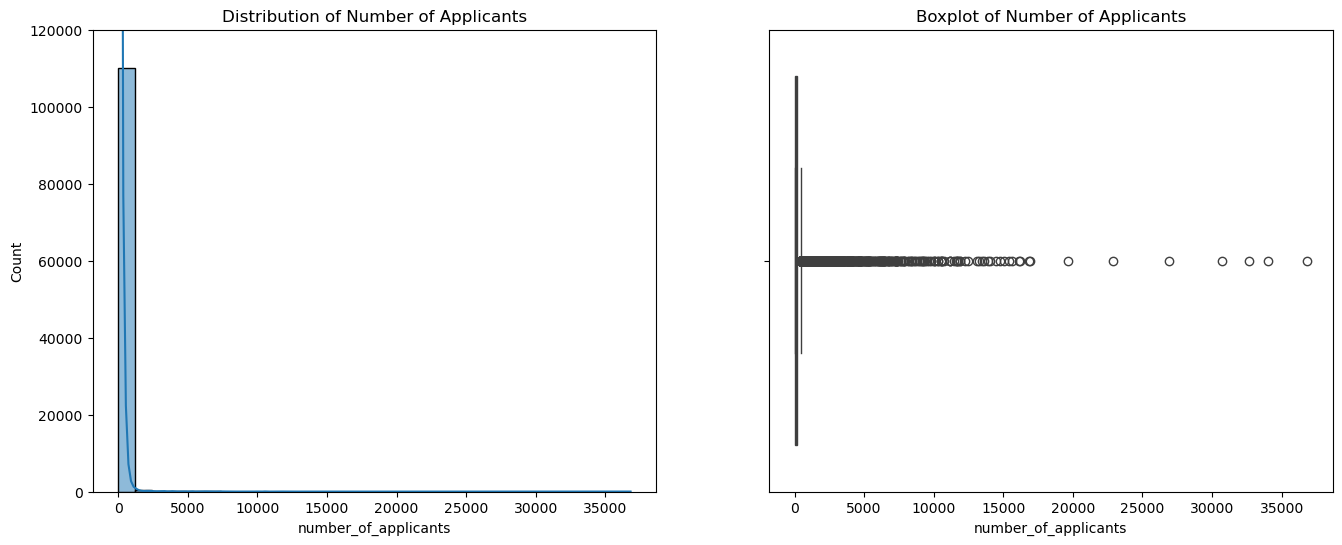

In [20]:
# number_of_applicants
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
sns.histplot(df['number_of_applicants'], bins=30, kde=True)
plt.ylim(0,120000)
plt.title('Distribution of Number of Applicants')

plt.subplot(1,2,2)
sns.boxplot(x='number_of_applicants', data=df)
plt.title('Boxplot of Number of Applicants')

plt.show()

for No_of_applicant there are outlier it is need to be removed above 12000  

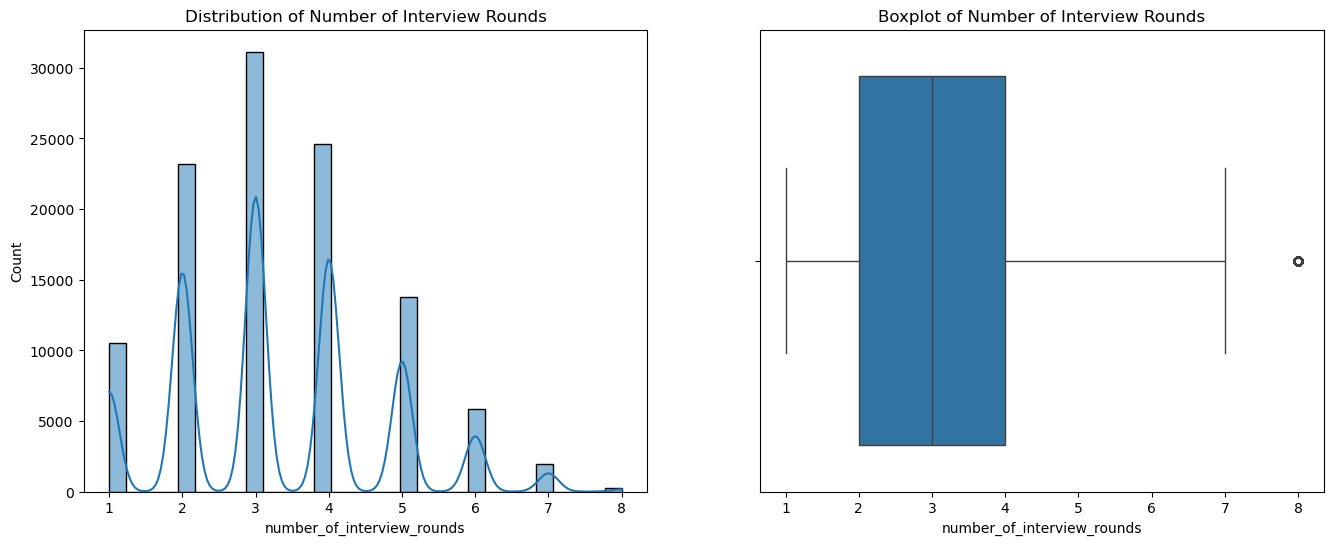

In [21]:
# number_of_interview_rounds
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
sns.histplot(df['number_of_interview_rounds'], bins=30, kde=True)
plt.title('Distribution of Number of Interview Rounds')

plt.subplot(1,2,2)
sns.boxplot(x='number_of_interview_rounds', data=df)
plt.title('Boxplot of Number of Interview Rounds')

plt.show()

maximum company conduct 2-4 round of interview

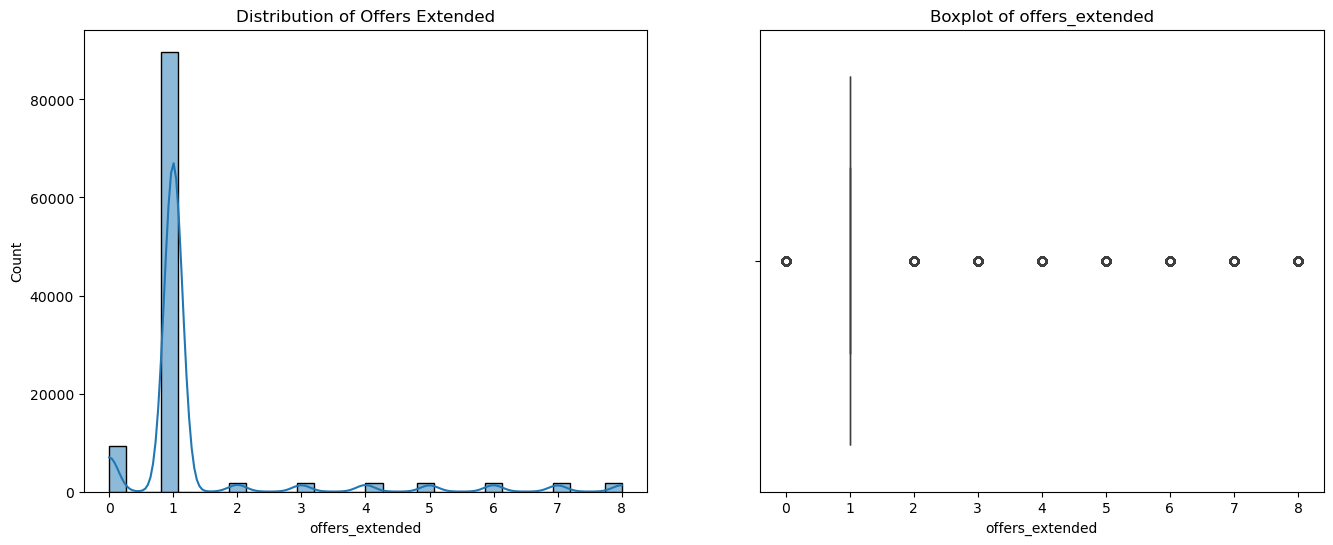

In [22]:
# offers_extended
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
sns.histplot(df['offers_extended'], bins=30, kde=True)
plt.title('Distribution of Offers Extended')

plt.subplot(1,2,2)
sns.boxplot(x='offers_extended', data=df)
plt.title('Boxplot of offers_extended')

plt.show()

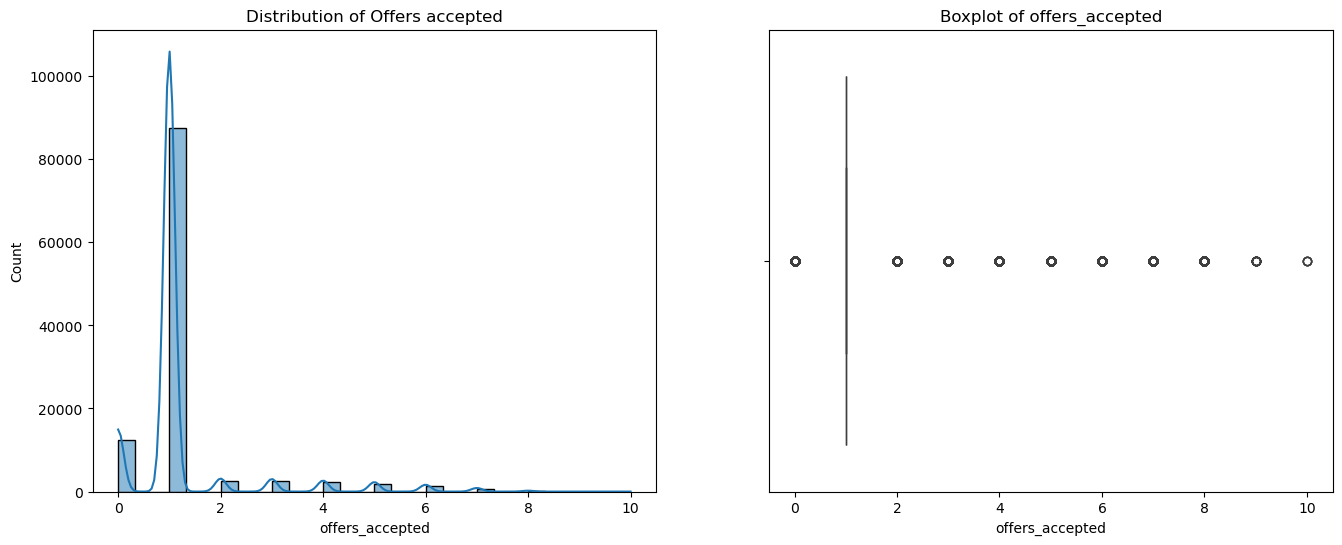

In [23]:
# offers_accepted
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
sns.histplot(df['offers_accepted'], bins=30, kde=True)
plt.title('Distribution of Offers accepted')

plt.subplot(1,2,2)
sns.boxplot(x='offers_accepted', data=df)
plt.title('Boxplot of offers_accepted')

plt.show()

Almost every company extend only 1 offer and applicant accept only one offer 

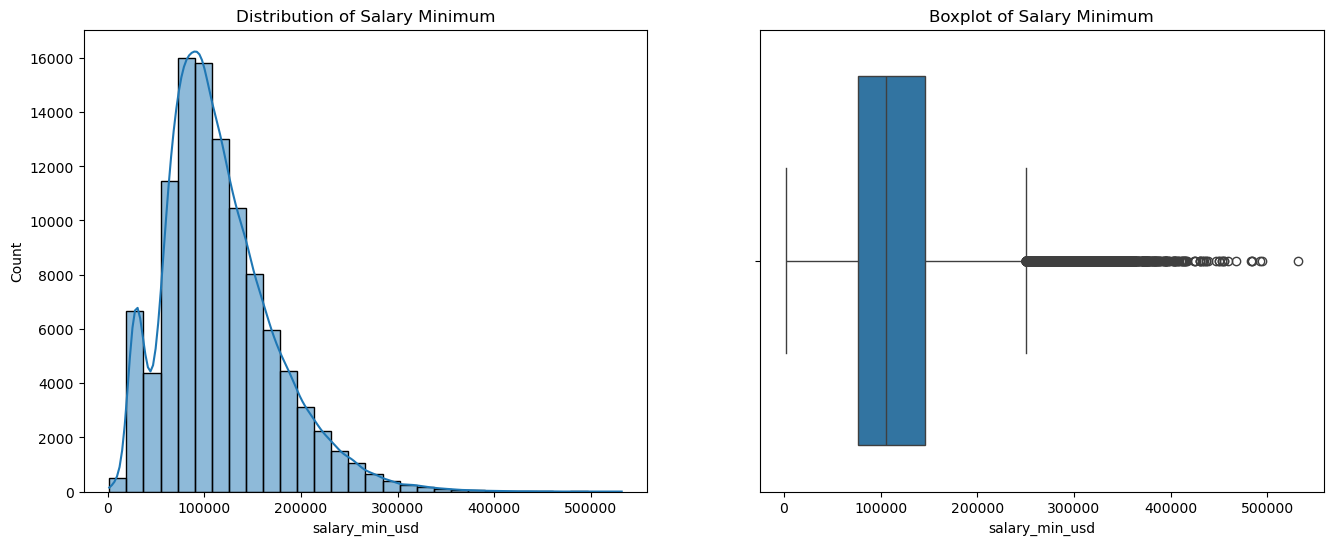

In [24]:
# salary_min_usd
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
sns.histplot(df['salary_min_usd'], bins=30, kde=True)
plt.title('Distribution of Salary Minimum')

plt.subplot(1,2,2)
sns.boxplot(x='salary_min_usd', data=df)
plt.title('Boxplot of Salary Minimum')

plt.show()

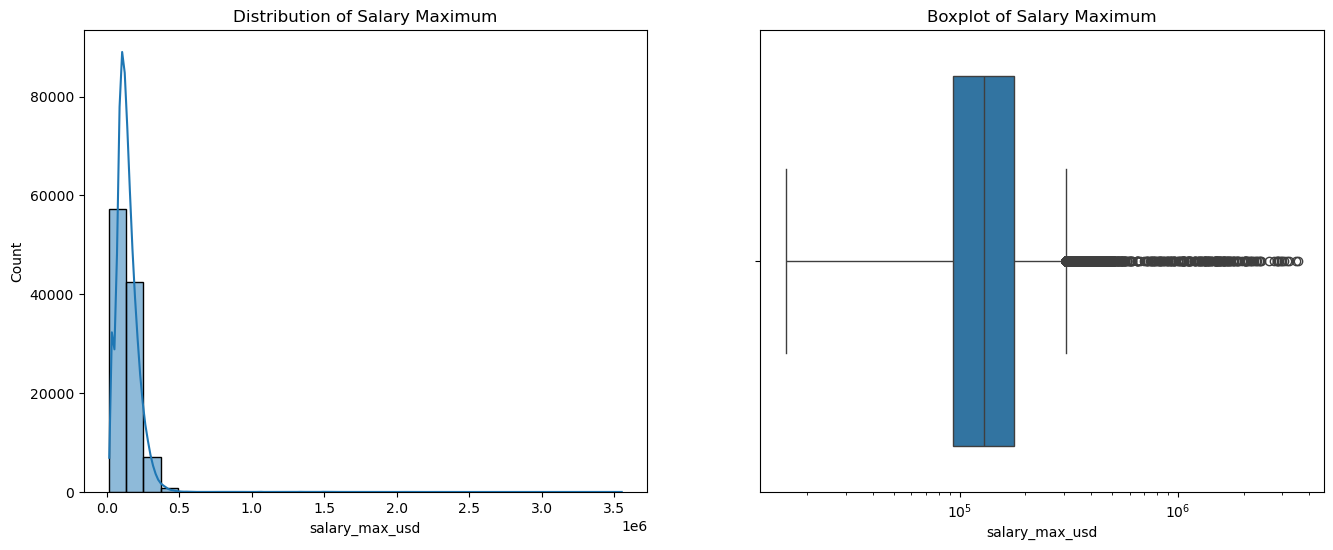

In [25]:
# salary_max_usd
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
sns.histplot(df['salary_max_usd'], bins=30, kde=True)
plt.title('Distribution of Salary Maximum')

plt.subplot(1,2,2)
sns.boxplot(x='salary_max_usd', data=df)
plt.xscale('log')
plt.title('Boxplot of Salary Maximum')

plt.show()

In [26]:
for col in df.select_dtypes(include=["object"]):
    print(f"Column: {col}")
    print(df[col].unique())
    print("\n")

Column: job_id
['JOB018462' 'JOB110011' 'JOB073462' ... 'JOB006013' 'JOB063108'
 'JOB006559']


Column: company_name
['DriftLearn' 'AnchorBuzz Labs' 'KiteSphere' 'AetherNode Co'
 'QuantumBuzz Technologies' 'SpireCloud' 'NimbusFlow'
 'VantageChain Systems' 'PinnacleBlock' 'EchoVita Technologies'
 'MeridianToken' 'CobaltWealth' 'BeaconStack Co'
 'LumenArcade Technologies' 'EchoCortex Co' 'VertexCompute Inc'
 'PinnacleLedger Labs' 'AstraCognition' 'PrismSphere' 'NovaFleet'
 'PrismRoute Technologies' 'MeridianShield Labs' 'DriftGame Co'
 'DriftSkill Inc' 'RidgeAI' 'CatalystWellness Inc' 'EchoTrade Co'
 'OnyxBuzz Inc' 'NexusShield' 'FusionTrade' 'VantageSphere'
 'CobaltAcademy Labs' 'SolaceFlow Inc' 'AstraSuite' 'SolaceShop Labs'
 'VantageFlow' 'DriftGame' 'LumenNeural Inc' 'LatticeReach Systems'
 'SpireBazaar Co' 'OrbitWorks' 'KitePlay Inc' 'NimbusGame Technologies'
 'LUMENARCADE TECHNOLOGIES' 'DriftShield Labs' '  OnyxBuzz Co'
 'CrestMind Systems' 'NovaCare' 'TideFort' 'AetherFleet Inc'
 

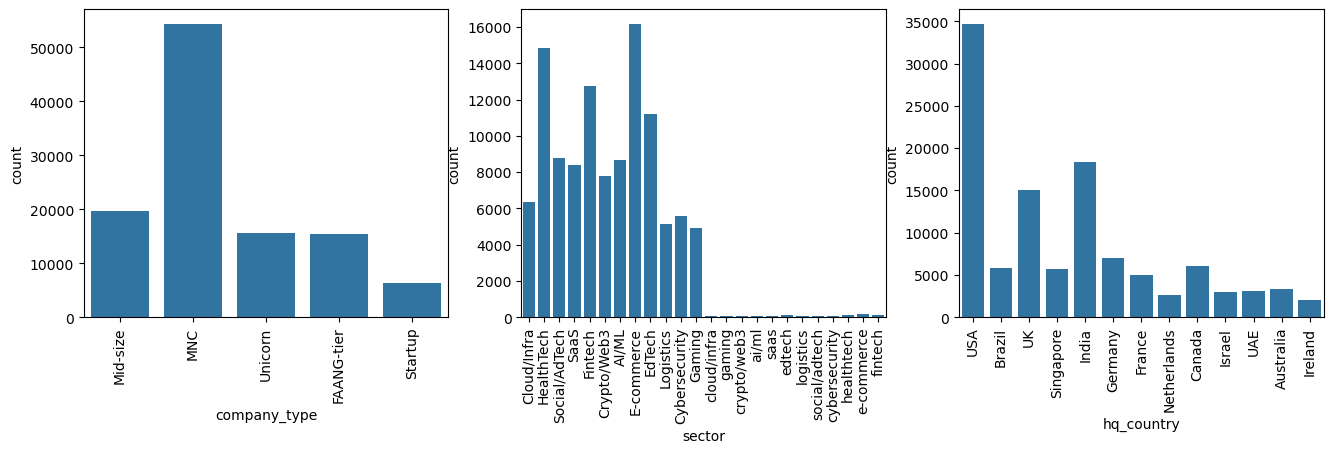

In [27]:
# company_type, sector and hq_country                      

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
sns.countplot(x=df["company_type"])
plt.xticks(rotation=90)
plt.subplot(1,3,2)
sns.countplot(x=df["sector"])
plt.xticks(rotation=90)
plt.subplot(1,3,3)
sns.countplot(x=df["hq_country"])
plt.xticks(rotation=90)
plt.show()


- Most of the hirings are from MNC 
- HealthTech ,FinTech , E-commerce , EdTech are the popular sector for hiring
- Majority of hiring are form USA

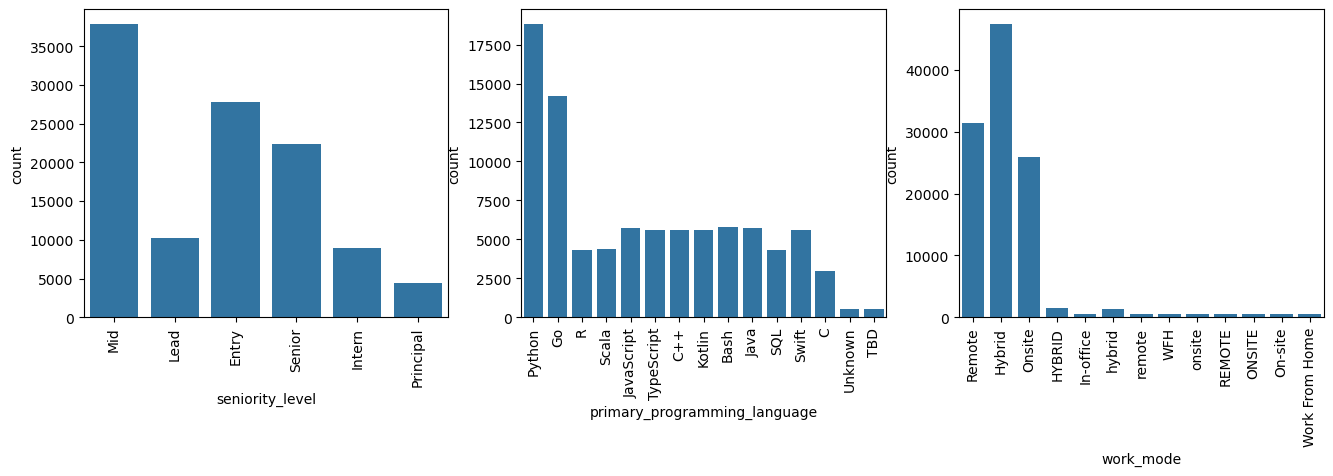

In [28]:
# seniority_level, work_mode and primary_programming_language                        

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
sns.countplot(x=df["seniority_level"])
plt.xticks(rotation=90)
plt.subplot(1,3,2)
sns.countplot(x=df["primary_programming_language"])
plt.xticks(rotation=90)
plt.subplot(1,3,3)
sns.countplot(x=df["work_mode"])
plt.xticks(rotation=90)
plt.show()


- Hiring is mostly for Mid,Entry,Senior level
- Go and Python is in demand in industry
- Hybrid, Remote and Onsite Mode is more preffered as compare to other

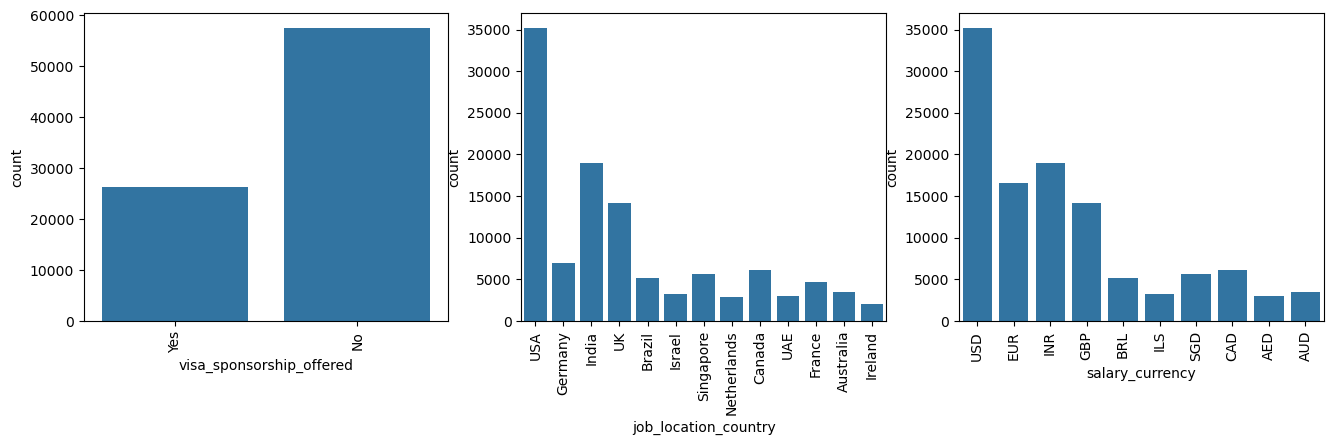

In [29]:
# visa_sponsorship_offered, job_location_country and salary_currency                        

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
sns.countplot(x=df["visa_sponsorship_offered"])
plt.xticks(rotation=90)
plt.subplot(1,3,2)
sns.countplot(x=df["job_location_country"])
plt.xticks(rotation=90)
plt.subplot(1,3,3)
sns.countplot(x=df["salary_currency"])
plt.xticks(rotation=90)
plt.show()


- As we see clearly mostly job are form USA and India so Salaray is also inn INR and USD
- VISA Sponsorship offrered are note there in most of the company

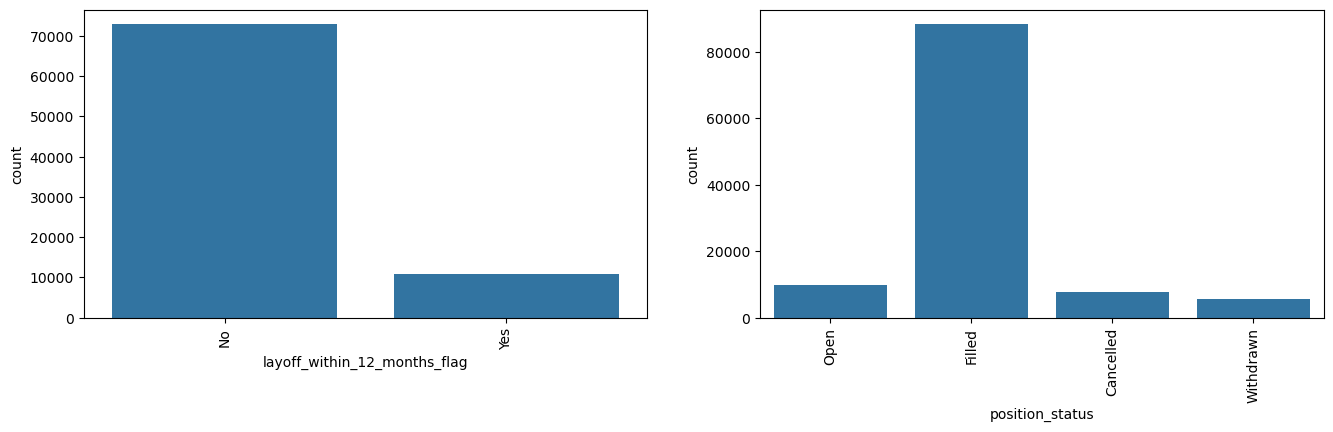

In [30]:
# layoff_within_12_months_flag, position_status                         

plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
sns.countplot(x=df["layoff_within_12_months_flag"])
plt.xticks(rotation=90)
plt.subplot(1,2,2)
sns.countplot(x=df["position_status"])
plt.xticks(rotation=90)

plt.show()


- Mostly applicant stay the company and do not resign 
- MOstly jon Hiring are filled

## BIVARIATE ANALYISIS

<Axes: >

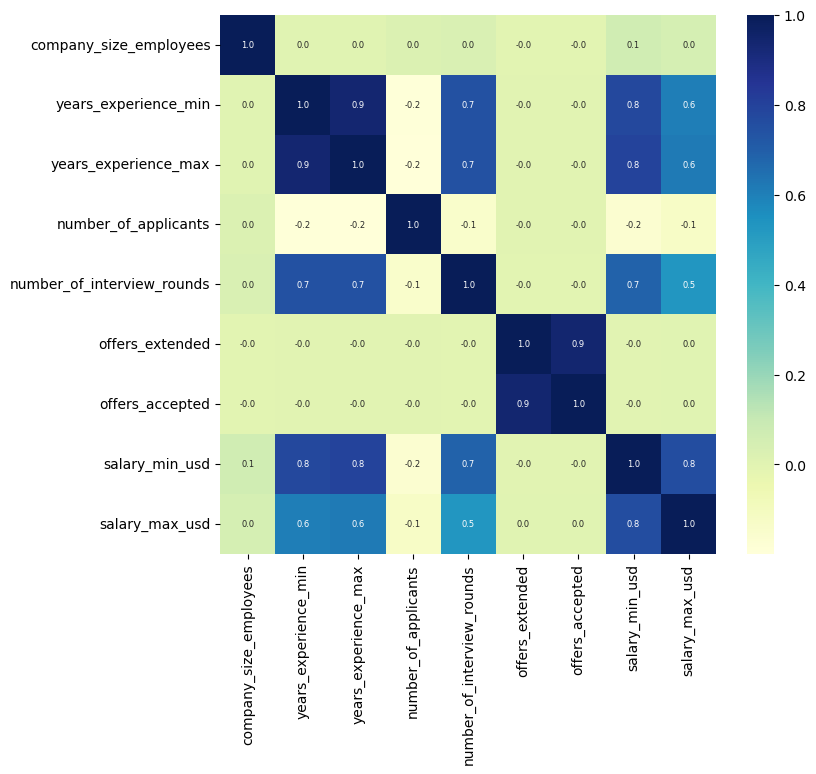

In [31]:
plt.figure(figsize=(8,7))
sns.heatmap(df.corr(numeric_only = True) , annot = True , fmt = '.1f' , cmap = 'YlGnBu' , annot_kws = {'size':6})

## With the help of heatmap we decide to compare following column
- Years_Expierience_min vs salary_min_usd, Years_Expierience_max, number_of_interview_rounds
- Years_Expierience_max vs number_of_interview_rounds
- offers_extended vs offers_accepted

<Axes: xlabel='salary_max_usd', ylabel='years_experience_max'>

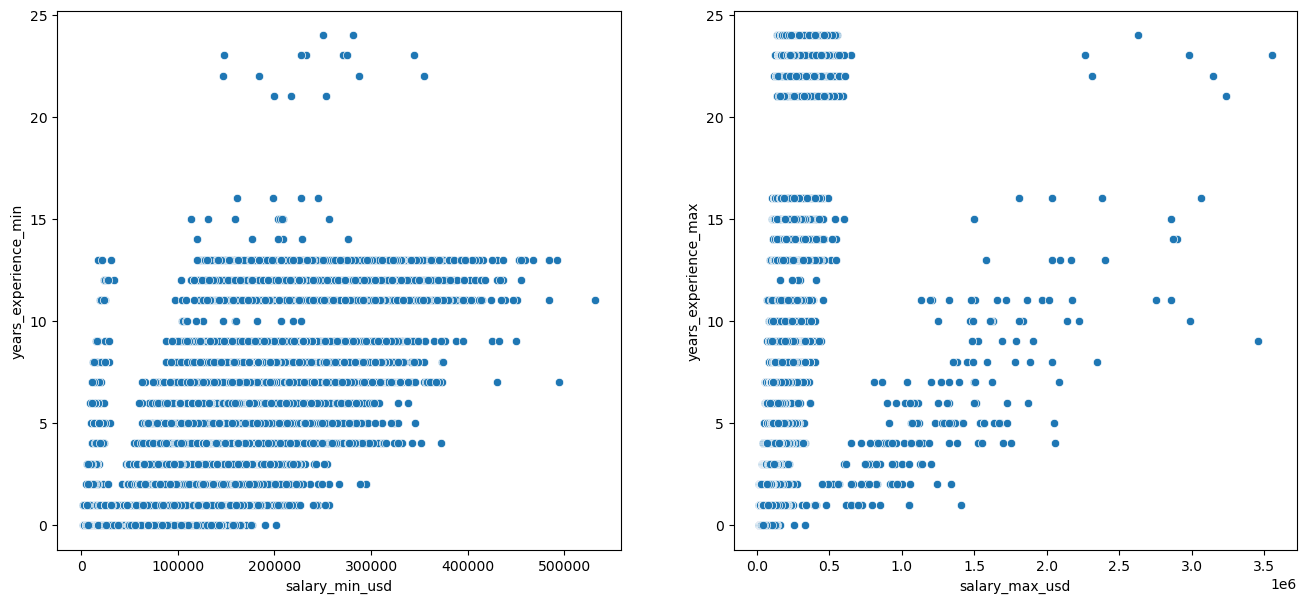

In [32]:
plt.figure(figsize=(16,7))
plt.subplot(1,2,1)
sns.scatterplot(x='salary_min_usd', y='years_experience_min', data=df)

plt.subplot(1,2,2)
sns.scatterplot(x='salary_max_usd', y='years_experience_max', data=df)

- As we increase min and max axpierence than min and max salary also increased

<Axes: xlabel='number_of_interview_rounds', ylabel='years_experience_min'>

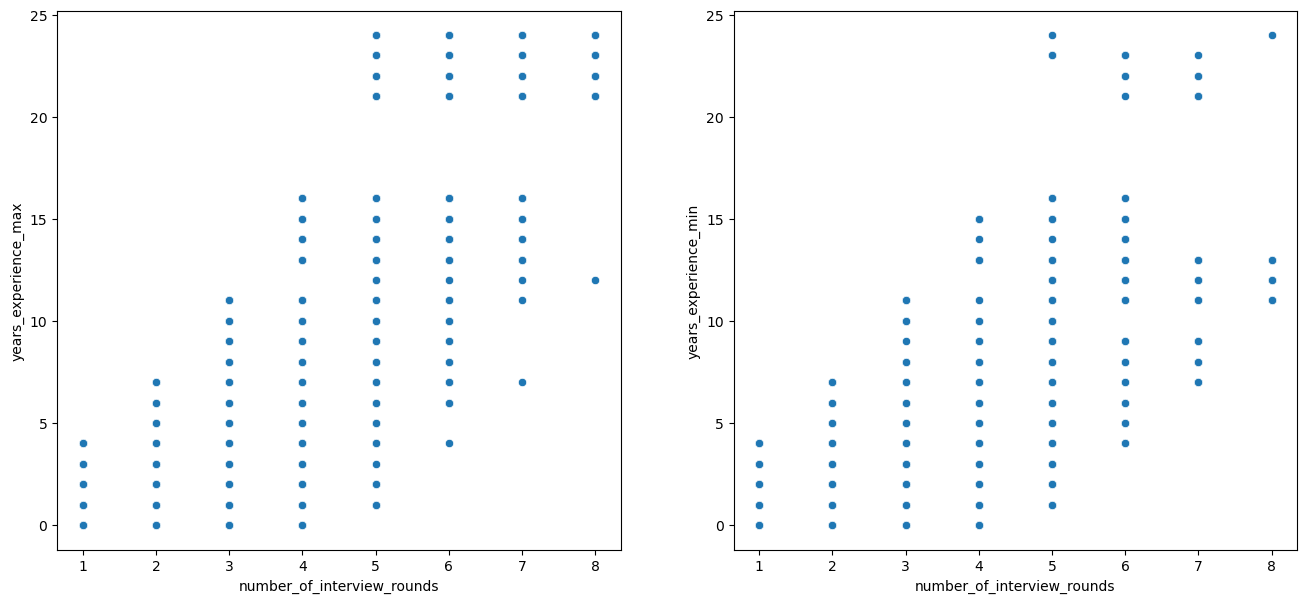

In [33]:
plt.figure(figsize=(16,7))
plt.subplot(1,2,1)
sns.scatterplot(x='number_of_interview_rounds', y='years_experience_max', data=df)

plt.subplot(1,2,2)
sns.scatterplot(x='number_of_interview_rounds', y='years_experience_min', data=df)


It is clearly show for higher expierience there is more no of interview rounds

<Axes: xlabel='offers_extended', ylabel='offers_accepted'>

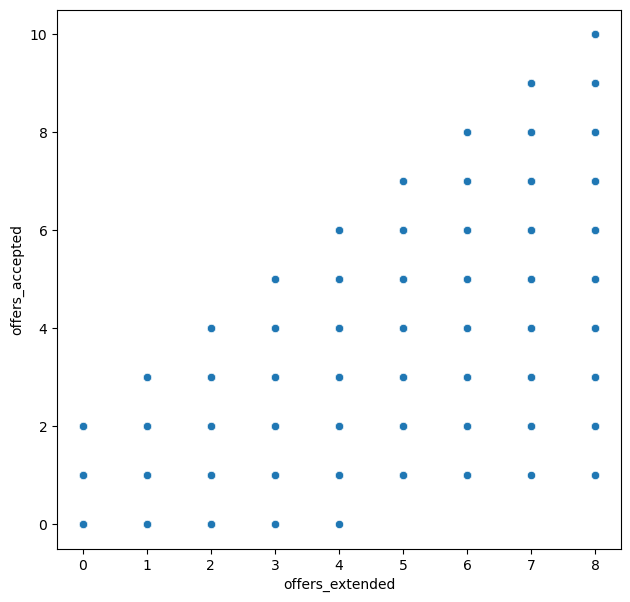

In [34]:
plt.figure(figsize=(16,7))
plt.subplot(1,2,1)
sns.scatterplot(x='offers_extended', y='offers_accepted', data=df)

As the offer extend the acception is also increase

In [35]:
df.columns

Index(['job_id', 'company_name', 'company_type', 'sector',
       'company_size_employees', 'hq_country', 'job_role', 'seniority_level',
       'years_experience_min', 'years_experience_max', 'required_tech_stack',
       'primary_programming_language', 'work_mode', 'visa_sponsorship_offered',
       'job_location_country', 'job_location_city', 'salary_currency',
       'posting_date', 'application_deadline', 'date_position_filled',
       'position_status', 'number_of_applicants', 'number_of_interview_rounds',
       'offers_extended', 'offers_accepted', 'salary_min_usd',
       'salary_max_usd', 'layoff_within_12_months_flag'],
      dtype='object')

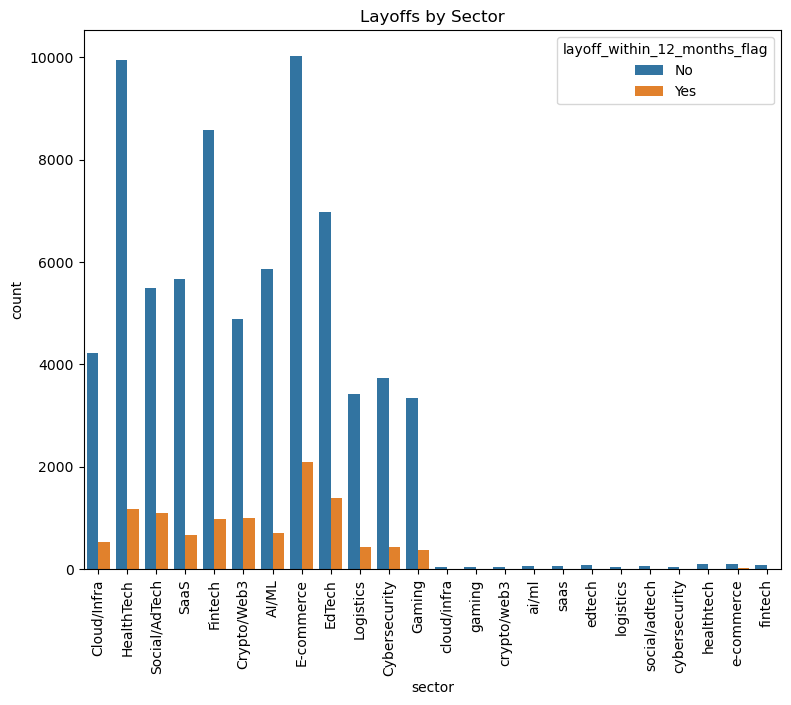

In [38]:
plt.figure(figsize=(9,7))

sns.countplot(data=df, x='sector', hue='layoff_within_12_months_flag')
plt.title('Layoffs by Sector')
plt.xticks(rotation=90)
plt.show()


For every Sector there is no layoff within 12 month

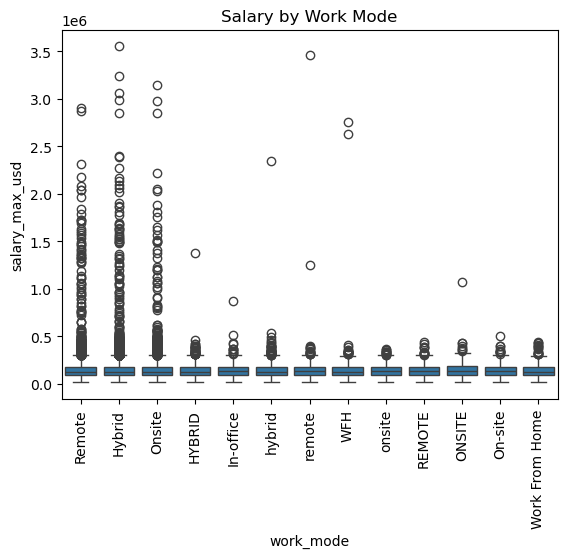

In [40]:
sns.boxplot(data=df, x='work_mode', y='salary_max_usd')
plt.title('Salary by Work Mode')
plt.xticks(rotation=90)
plt.show()


For Remote, Hybrid,Onsite there is max salary

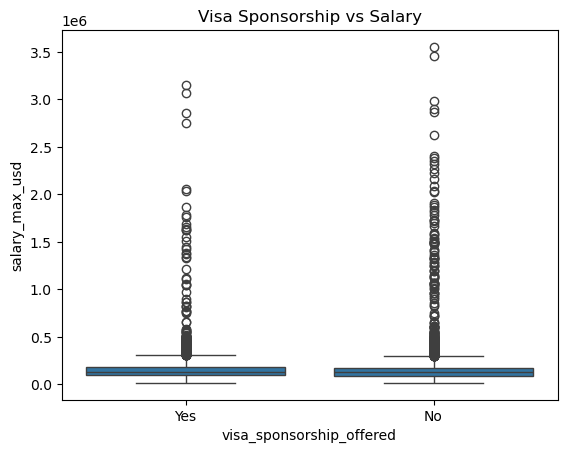

In [42]:
sns.boxplot(data=df, x='visa_sponsorship_offered', y='salary_max_usd')
plt.title('Visa Sponsorship vs Salary')
plt.show()


## MultiVariant

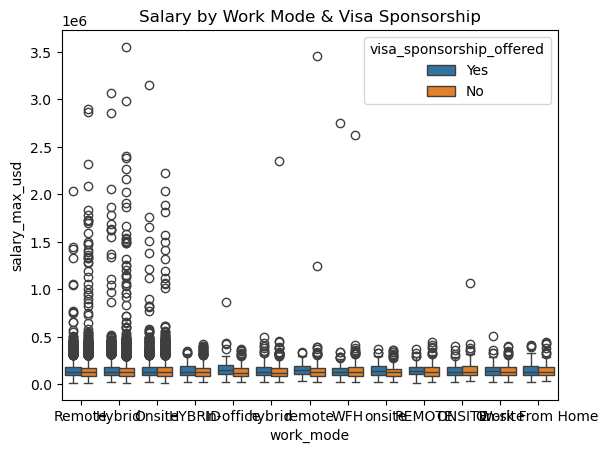

In [46]:
sns.boxplot(data=df, x='work_mode', y='salary_max_usd', hue='visa_sponsorship_offered')
plt.title('Salary by Work Mode & Visa Sponsorship')
plt.show()
